# NBA Feature Engineering

À partir de `nba_processed.csv`, on va :
1. Analyser et visualiser les features
2. Créer des features dérivées plus fines
3. Sélectionner les features les plus importantes
4. Normaliser pour le QNN
5. Créer le train/val split temporel
6. Sauvegarder `nba_ml_ready.csv`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Imports OK')

Imports OK


In [3]:
df = pd.read_csv('data/nba_processed.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Shape : {df.shape}')
print(f'Période : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Saisons : {df["home_season"].unique()}')
df.head(3)

Shape : (3890, 57)
Période : 2022-10-24 → 2025-06-22
Saisons : <ArrowStringArray>
['2022-23', '2023-24', '2024-25']
Length: 3, dtype: str


,GAME_ID,date,home_season,home_season_type,home_TEAM_ABBREVIATION,away_TEAM_ABBREVIATION,home_win,point_diff,home_PTS,away_PTS,home_FG_PCT,away_FG_PCT,home_FG3_PCT,away_FG3_PCT,home_FT_PCT,away_FT_PCT,home_REB,away_REB,home_AST,away_AST,home_TOV,away_TOV,home_PLUS_MINUS,away_PLUS_MINUS,adv_home_estimatedNetRating,adv_away_estimatedNetRating,adv_home_estimatedOffensiveRating,adv_away_estimatedOffensiveRating,adv_home_estimatedDefensiveRating,adv_away_estimatedDefensiveRating,adv_home_estimatedPace,adv_away_estimatedPace,adv_home_effectiveFieldGoalPercentage,adv_away_effectiveFieldGoalPercentage,adv_home_trueShootingPercentage,adv_away_trueShootingPercentage,adv_home_PIE,adv_away_PIE,net_rating_diff,pace_diff,efg_diff,home_rest_days,away_rest_days,home_is_b2b,away_is_b2b,rest_diff,b2b_advantage,home_roll_won_10,away_roll_won_10,home_roll_pts_for_10,away_roll_pts_for_10,home_roll_pts_against_10,away_roll_pts_against_10,home_roll_pt_diff_10,away_roll_pt_diff_10,win_pct_diff_10,pt_diff_diff_10
0,22200049,2022-10-24,2022-23,Regular Season,MEM,BKN,1,10,134,124,0.500,0.540,0.471,0.310,0.774,0.808,38,35,21,27,9,11,10,-10,51.000,-51.000,683.700,632.700,632.700,683.700,19.600,19.600,0.585,0.592,0.622,0.630,0.518,0.482,102.000,0.000,-0.007,1.000,2.000,0,0,-1.000,0,0.667,NaN,113.333,NaN,123.667,NaN,-10.333,NaN,NaN,NaN
1,22200044,2022-10-24,2022-23,Regular Season,PHI,IND,1,14,120,106,0.475,0.422,0.442,0.273,0.893,0.783,39,47,25,27,8,13,14,-14,81.300,-81.300,645.200,563.800,563.800,645.200,18.700,18.700,0.594,0.489,0.650,0.529,0.583,0.417,162.600,0.000,0.105,1.000,1.000,0,0,0.000,0,0.000,0.333,103.333,121.667,110.000,122.000,-6.667,-0.333,-0.333,-6.333
2,22200050,2022-10-24,2022-23,Regular Season,MIN,SAS,0,-9,106,115,0.442,0.457,0.258,0.324,0.917,0.538,50,50,24,37,16,13,-9,9,-33.300,33.300,519.600,552.900,552.900,519.600,20.600,20.600,0.488,0.514,0.549,0.519,0.480,0.520,-66.600,0.000,-0.026,0.000,1.000,1,0,-1.000,-1,0.667,0.667,119.000,117.667,115.333,122.667,3.667,-5.000,0.000,8.667


## 1. Analyse exploratoire des features

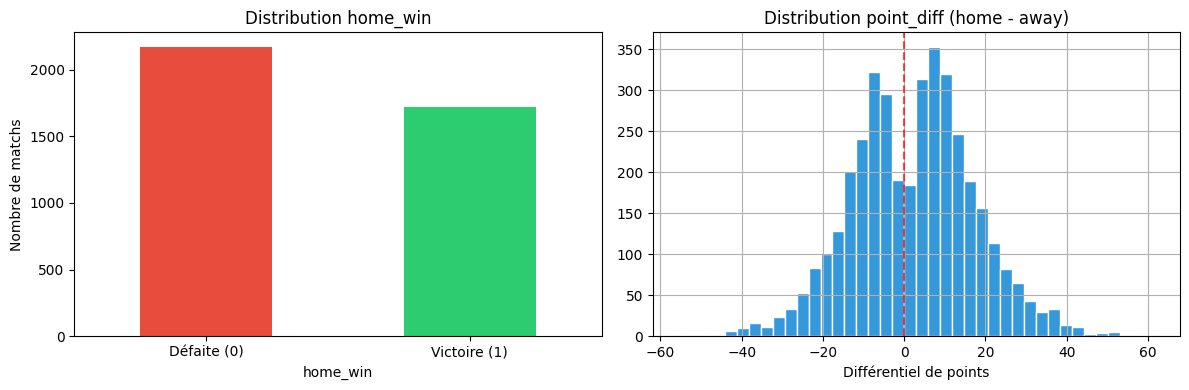

Taux victoire domicile : 55.8%


In [4]:
# Distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# home_win
df['home_win'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribution home_win')
axes[0].set_xticklabels(['Défaite (0)', 'Victoire (1)'], rotation=0)
axes[0].set_ylabel('Nombre de matchs')

# point_diff
df['point_diff'].hist(bins=40, ax=axes[1], color='#3498db', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Distribution point_diff (home - away)')
axes[1].set_xlabel('Différentiel de points')

plt.tight_layout()
plt.savefig('data/nba_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Taux victoire domicile : {df["home_win"].mean():.1%}')

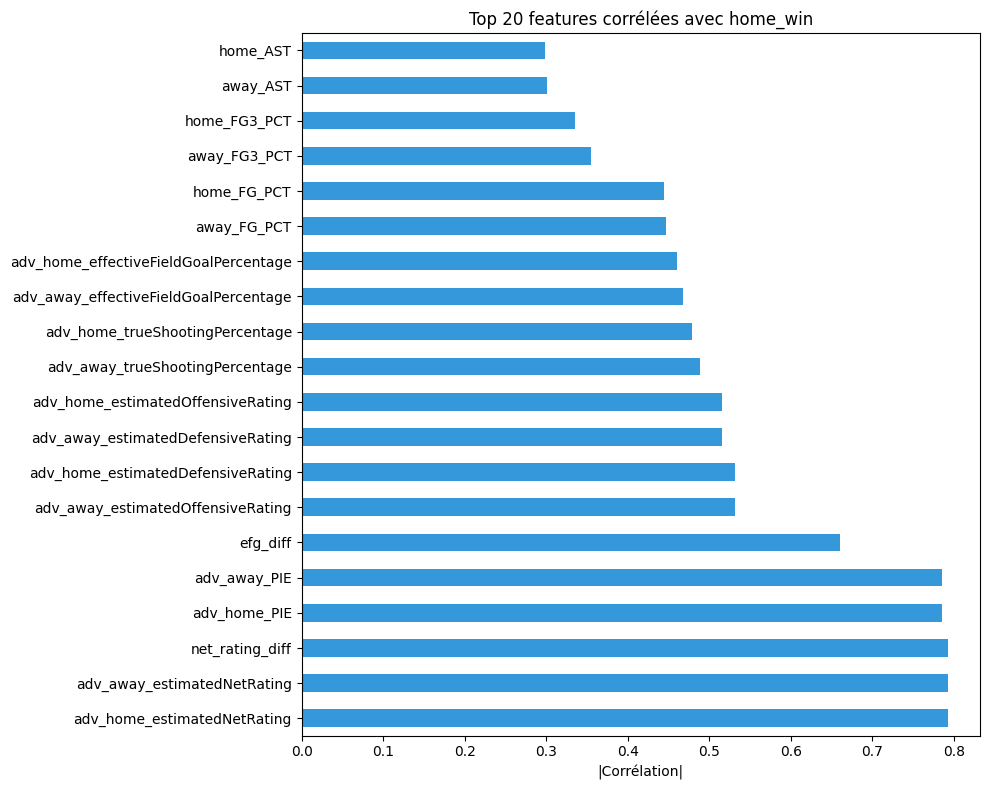

Top 10 features :
adv_home_estimatedNetRating         0.793
adv_away_estimatedNetRating         0.793
net_rating_diff                     0.793
adv_home_PIE                        0.786
adv_away_PIE                        0.786
efg_diff                            0.660
adv_away_estimatedOffensiveRating   0.531
adv_home_estimatedDefensiveRating   0.531
adv_away_estimatedDefensiveRating   0.516
adv_home_estimatedOffensiveRating   0.516


In [5]:
# Corrélations avec home_win
num_cols = df.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in ['home_win', 'point_diff',
                                               'home_PTS', 'away_PTS',
                                               'home_PLUS_MINUS', 'away_PLUS_MINUS']]

corrs = df[num_cols].corrwith(df['home_win']).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corrs.head(20).plot(kind='barh', color='#3498db')
plt.title('Top 20 features corrélées avec home_win')
plt.xlabel('|Corrélation|')
plt.tight_layout()
plt.savefig('data/nba_correlations.png', dpi=100, bbox_inches='tight')
plt.show()

print('Top 10 features :')
print(corrs.head(10).to_string())

In [6]:
# Impact back-to-back
print('Impact back-to-back sur home_win :')
b2b_impact = df.groupby(['home_is_b2b', 'away_is_b2b'])['home_win'].agg(['mean', 'count'])
b2b_impact.columns = ['win_rate', 'n_matchs']
b2b_impact['win_rate'] = b2b_impact['win_rate'].map('{:.1%}'.format)
print(b2b_impact)

print('\nImpact jours de repos :')
print(df.groupby('home_rest_days')['home_win'].agg(['mean', 'count']).round(3))

Impact back-to-back sur home_win :
                        win_rate  n_matchs
home_is_b2b away_is_b2b                   
0           0              55.8%      2812
            1              62.7%       499
1           0              47.4%       399
            1              55.6%       180

Impact jours de repos :
                mean  count
home_rest_days             
0.000          0.499    579
1.000          0.565   2422
2.000          0.574    605
3.000          0.624    133
4.000          0.581     31
5.000          0.700     20
6.000          0.600     15
7.000          0.550     40
8.000          0.600     10
9.000          0.667      3
10.000         1.000      1
14.000         0.419     31


## 2. Features dérivées

Création de features plus fines à partir des données existantes.

In [7]:
def add_derived_features(df):
    df = df.copy()

    # ── Ratios offensif/défensif ──────────────────────────────
    # Ratio Net Rating : mesure la domination relative
    df['net_rating_ratio'] = (
        df['adv_home_estimatedNetRating'] /
        (df['adv_away_estimatedNetRating'].abs() + 1e-6)
    )

    # Différentiel PIE (Player Impact Estimate agrégé)
    if 'adv_home_PIE' in df.columns and 'adv_away_PIE' in df.columns:
        df['PIE_diff'] = df['adv_home_PIE'] - df['adv_away_PIE']

    # ── Momentum ──────────────────────────────────────────────
    # Différentiel de forme récente
    if 'home_roll_won_10' in df.columns:
        df['momentum_diff'] = df['home_roll_won_10'] - df['away_roll_won_10']
        df['scoring_momentum'] = df['home_roll_pts_for_10'] - df['away_roll_pts_for_10']
        df['defense_momentum'] = df['away_roll_pts_against_10'] - df['home_roll_pts_against_10']

    # ── Fatigue composite ─────────────────────────────────────
    # Score de fatigue : combine B2B et jours de repos
    df['home_fatigue_score'] = df['home_is_b2b'] * 3 + np.exp(-df['home_rest_days'] / 3)
    df['away_fatigue_score'] = df['away_is_b2b'] * 3 + np.exp(-df['away_rest_days'] / 3)
    df['fatigue_advantage']  = df['away_fatigue_score'] - df['home_fatigue_score']

    # ── Efficacité offensive/défensive ────────────────────────
    if all(c in df.columns for c in ['adv_home_estimatedOffensiveRating',
                                      'adv_away_estimatedDefensiveRating']):
        # Avantage offensif domicile vs défense visiteur
        df['off_vs_def_home'] = (df['adv_home_estimatedOffensiveRating'] -
                                  df['adv_away_estimatedDefensiveRating'])
        # Avantage offensif visiteur vs défense domicile
        df['off_vs_def_away'] = (df['adv_away_estimatedOffensiveRating'] -
                                  df['adv_home_estimatedDefensiveRating'])
        df['matchup_advantage'] = df['off_vs_def_home'] - df['off_vs_def_away']

    # ── Saison type ───────────────────────────────────────────
    df['is_playoffs'] = (df['home_season_type'] == 'Playoffs').astype(int)

    return df

df = add_derived_features(df)

new_features = ['net_rating_ratio', 'PIE_diff', 'momentum_diff',
                'scoring_momentum', 'defense_momentum',
                'home_fatigue_score', 'away_fatigue_score', 'fatigue_advantage',
                'off_vs_def_home', 'off_vs_def_away', 'matchup_advantage',
                'is_playoffs']

print('Nouvelles features créées :')
for f in new_features:
    if f in df.columns:
        corr = df[f].corr(df['home_win'])
        print(f'  {f:35s} corr={corr:+.3f}')

Nouvelles features créées :
  net_rating_ratio                    corr=+0.969
  PIE_diff                            corr=+0.786
  momentum_diff                       corr=+0.258
  scoring_momentum                    corr=+0.178
  defense_momentum                    corr=+0.180
  home_fatigue_score                  corr=-0.050
  away_fatigue_score                  corr=+0.046
  fatigue_advantage                   corr=+0.074
  off_vs_def_home                     corr=+nan
  off_vs_def_away                     corr=+nan
  matchup_advantage                   corr=+nan
  is_playoffs                         corr=+0.014


## 3. Sélection des features

On utilise Random Forest pour identifier les features les plus importantes.  
On sélectionne ensuite ~16 features pour le QNN (contrainte budget qubits).

In [8]:
# Définir les features candidates
# On exclut les colonnes metadata et les cibles
EXCLUDE = [
    'GAME_ID', 'date', 'home_season', 'home_season_type',
    'home_TEAM_ABBREVIATION', 'away_TEAM_ABBREVIATION',
    'home_win', 'point_diff',
    'home_PTS', 'away_PTS',          # résultats → data leakage
    'home_PLUS_MINUS', 'away_PLUS_MINUS',  # résultats → data leakage
]

FEATURES = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in EXCLUDE]

print(f'Features candidates : {len(FEATURES)}')

# Dataset sans NaN pour la sélection
df_sel = df[FEATURES + ['home_win']].dropna()
X_sel = df_sel[FEATURES]
y_sel = df_sel['home_win']

print(f'Matchs disponibles pour sélection : {len(df_sel)}')

Features candidates : 57
Matchs disponibles pour sélection : 3887


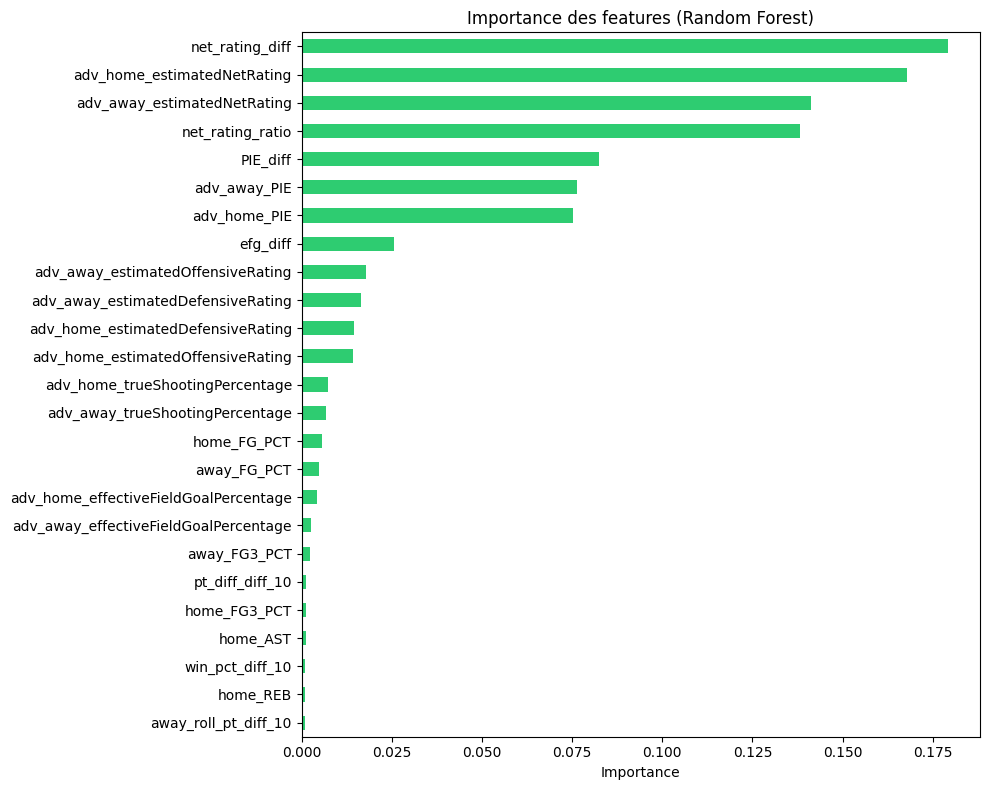

Top 20 features :
net_rating_diff                         0.179
adv_home_estimatedNetRating             0.168
adv_away_estimatedNetRating             0.141
net_rating_ratio                        0.138
PIE_diff                                0.083
adv_away_PIE                            0.076
adv_home_PIE                            0.075
efg_diff                                0.026
adv_away_estimatedOffensiveRating       0.018
adv_away_estimatedDefensiveRating       0.017
adv_home_estimatedDefensiveRating       0.014
adv_home_estimatedOffensiveRating       0.014
adv_home_trueShootingPercentage         0.007
adv_away_trueShootingPercentage         0.007
home_FG_PCT                             0.006
away_FG_PCT                             0.005
adv_home_effectiveFieldGoalPercentage   0.004
adv_away_effectiveFieldGoalPercentage   0.003
away_FG3_PCT                            0.002
pt_diff_diff_10                         0.001


In [9]:
# Random Forest pour importance des features
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_sel, y_sel)

importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(25).plot(kind='barh', color='#2ecc71')
plt.title('Importance des features (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('data/nba_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('Top 20 features :')
print(importances.head(20).to_string())

In [10]:
# Sélection finale :
# - Top features pour XGBoost (pas de contrainte)
# - Top 16 features pour QNN (contrainte budget qubits)

TOP_N_XGBOOST = 30
TOP_N_QNN     = 16   # = nombre de qubits

features_xgboost = importances.head(TOP_N_XGBOOST).index.tolist()
features_qnn     = importances.head(TOP_N_QNN).index.tolist()

print(f'Features XGBoost ({TOP_N_XGBOOST}) :')
print(features_xgboost)
print(f'\nFeatures QNN ({TOP_N_QNN} qubits) :')
print(features_qnn)

Features XGBoost (30) :
['net_rating_diff', 'adv_home_estimatedNetRating', 'adv_away_estimatedNetRating', 'net_rating_ratio', 'PIE_diff', 'adv_away_PIE', 'adv_home_PIE', 'efg_diff', 'adv_away_estimatedOffensiveRating', 'adv_away_estimatedDefensiveRating', 'adv_home_estimatedDefensiveRating', 'adv_home_estimatedOffensiveRating', 'adv_home_trueShootingPercentage', 'adv_away_trueShootingPercentage', 'home_FG_PCT', 'away_FG_PCT', 'adv_home_effectiveFieldGoalPercentage', 'adv_away_effectiveFieldGoalPercentage', 'away_FG3_PCT', 'pt_diff_diff_10', 'home_FG3_PCT', 'home_AST', 'win_pct_diff_10', 'home_REB', 'away_roll_pt_diff_10', 'away_REB', 'home_TOV', 'away_AST', 'away_FT_PCT', 'home_roll_pt_diff_10']

Features QNN (16 qubits) :
['net_rating_diff', 'adv_home_estimatedNetRating', 'adv_away_estimatedNetRating', 'net_rating_ratio', 'PIE_diff', 'adv_away_PIE', 'adv_home_PIE', 'efg_diff', 'adv_away_estimatedOffensiveRating', 'adv_away_estimatedDefensiveRating', 'adv_home_estimatedDefensiveRating'

In [41]:
# Features pré-match uniquement (pas de data leakage)
# Seules les rolling averages sur matchs PRÉCÉDENTS sont légitimes

PRE_MATCH_FEATURES = [
    # Forme récente (rolling sur matchs précédents)
    'home_roll_won_10',
    'away_roll_won_10',
    'home_roll_pts_for_10',
    'away_roll_pts_for_10',
    'home_roll_pts_against_10',
    'away_roll_pts_against_10',
    'home_roll_pt_diff_10',
    'away_roll_pt_diff_10',
    'pt_diff_diff_10',
    # Différentiels de forme
    'momentum_diff',
    'scoring_momentum',
    'defense_momentum',
    # Fatigue
    'home_rest_days',
    'away_rest_days',
    'home_is_b2b',
    'away_is_b2b',
    'rest_diff',
    'b2b_advantage',
    'home_fatigue_score',
    'away_fatigue_score',
    'fatigue_advantage',
    # Contexte
    'is_playoffs',
]

# Retirer de PRE_MATCH_FEATURES (car trop corrélées)
PRE_MATCH_FEATURES = [f for f in PRE_MATCH_FEATURES if f not in [
    'home_roll_won_10',      # corrélé avec home_roll_pt_diff_10
    'away_roll_won_10',      # corrélé avec away_roll_pt_diff_10
    'momentum_diff',         # corrélé avec pt_diff_diff_10
    'home_fatigue_score',    # corrélé avec home_is_b2b
    'away_fatigue_score',    # même logique
    'fatigue_advantage',     # corrélé avec b2b_advantage
]]

# Garder seulement celles disponibles dans df
PRE_MATCH_FEATURES = [f for f in PRE_MATCH_FEATURES if f in df.columns]

features_xgboost = PRE_MATCH_FEATURES
features_qnn     = PRE_MATCH_FEATURES[:16]  # max 16 qubits

print(f'Features XGBoost : {len(features_xgboost)}')
print(f'Features QNN     : {len(features_qnn)}')
print(f'\nFeatures QNN :')
for f in features_qnn:
    print(f'  {f}')

Features XGBoost : 16
Features QNN     : 16

Features QNN :
  home_roll_pts_for_10
  away_roll_pts_for_10
  home_roll_pts_against_10
  away_roll_pts_against_10
  home_roll_pt_diff_10
  away_roll_pt_diff_10
  pt_diff_diff_10
  scoring_momentum
  defense_momentum
  home_rest_days
  away_rest_days
  home_is_b2b
  away_is_b2b
  rest_diff
  b2b_advantage
  is_playoffs


## 4. Normalisation

**Critique pour le QNN** — les circuits quantiques utilisent AngleEmbedding  
qui encode les features comme des angles de rotation → must être dans [-π, π].

On utilise StandardScaler puis on clip à [-π, π].

In [42]:
# Split temporel AVANT normalisation pour éviter le data leakage
# Train : 2022-23 + 2023-24
# Val   : 2024-25

train_mask = df['home_season'].isin(['2022-23', '2023-24'])
val_mask   = df['home_season'] == '2024-25'

df_train = df[train_mask].dropna(subset=features_qnn + ['home_win', 'point_diff'])
df_val   = df[val_mask].dropna(subset=features_qnn + ['home_win', 'point_diff'])

print(f'Train : {len(df_train)} matchs ({df_train["home_season"].unique()})')
print(f'Val   : {len(df_val)} matchs ({df_val["home_season"].unique()})')
print(f'Taux home_win train : {df_train["home_win"].mean():.1%}')
print(f'Taux home_win val   : {df_val["home_win"].mean():.1%}')

Train : 2579 matchs (<ArrowStringArray>
['2022-23', '2023-24']
Length: 2, dtype: str)
Val   : 1309 matchs (<ArrowStringArray>
['2024-25']
Length: 1, dtype: str)
Taux home_win train : 56.4%
Taux home_win val   : 54.6%


In [43]:
# Normalisation StandardScaler — fit sur train seulement
scaler = StandardScaler()

X_train_xgb = pd.DataFrame(
    scaler.fit_transform(df_train[features_xgboost]),
    columns=features_xgboost
)
X_val_xgb = pd.DataFrame(
    scaler.transform(df_val[features_xgboost]),
    columns=features_xgboost
)

# Pour QNN : normaliser dans [-π, π]
scaler_qnn = StandardScaler()
X_train_qnn = scaler_qnn.fit_transform(df_train[features_qnn])
X_train_qnn = np.clip(X_train_qnn, -np.pi, np.pi)

X_val_qnn = scaler_qnn.transform(df_val[features_qnn])
X_val_qnn = np.clip(X_val_qnn, -np.pi, np.pi)

y_train = df_train['home_win'].values
y_val   = df_val['home_win'].values

y_train_diff = df_train['point_diff'].values
y_val_diff   = df_val['point_diff'].values

print(f'X_train_xgb : {X_train_xgb.shape}')
print(f'X_train_qnn : {X_train_qnn.shape}')
print(f'Range QNN   : [{X_train_qnn.min():.2f}, {X_train_qnn.max():.2f}]')

X_train_xgb : (2579, 16)
X_train_qnn : (2579, 16)
Range QNN   : [-3.14, 3.14]


## 5. Matrice de corrélation des features QNN

Vérifier qu'on n'a pas de features trop corrélées entre elles  
(multicolinéarité → réduit l'efficacité du QNN).

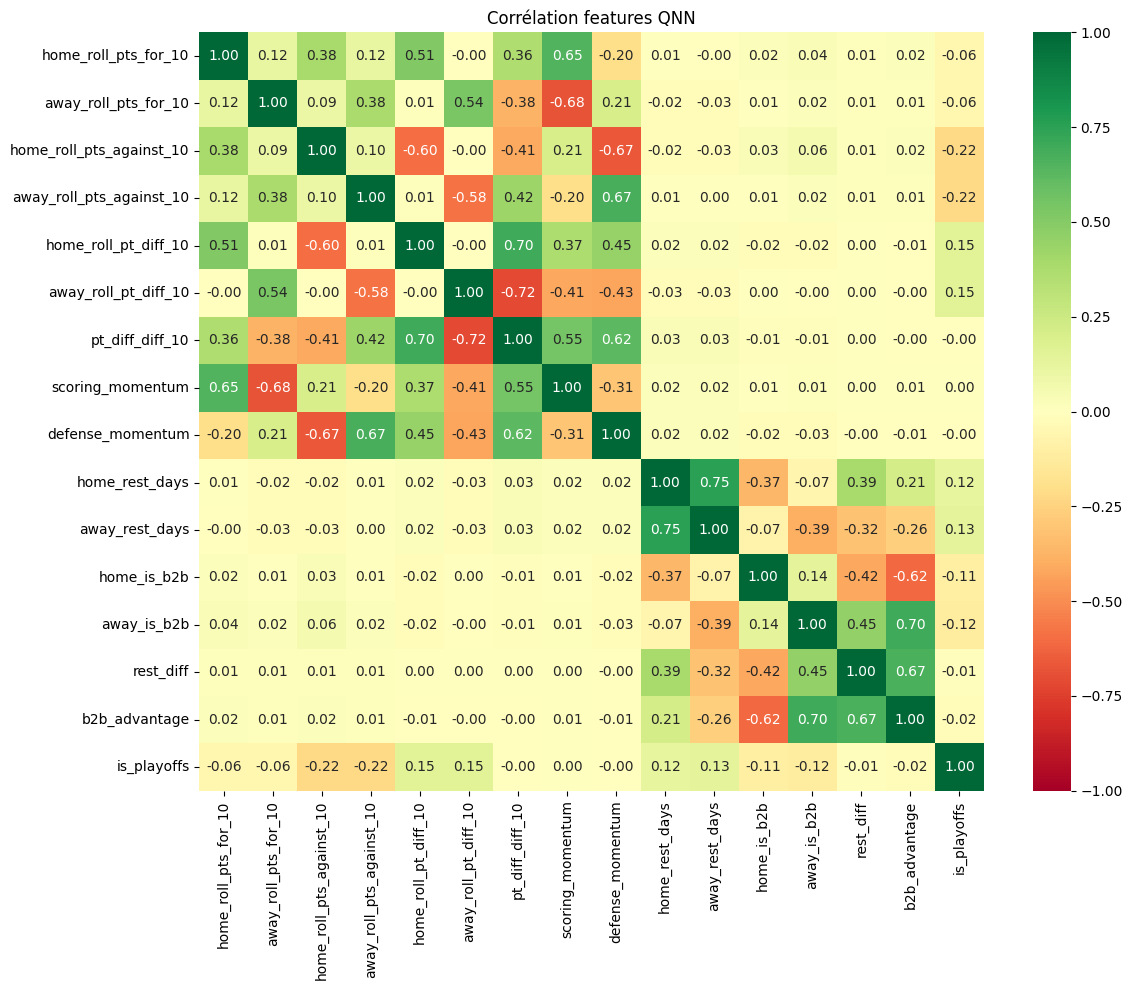

Aucune paire de features trop corrélée ✓


In [44]:
corr_matrix = df_train[features_qnn].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            xticklabels=[f.replace('adv_home_', '').replace('adv_away_', '')
                         for f in features_qnn],
            yticklabels=[f.replace('adv_home_', '').replace('adv_away_', '')
                         for f in features_qnn])
plt.title('Corrélation features QNN')
plt.tight_layout()
plt.savefig('data/nba_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Features trop corrélées (|r| > 0.85)
high_corr = []
for i in range(len(features_qnn)):
    for j in range(i+1, len(features_qnn)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append((features_qnn[i], features_qnn[j], r))

if high_corr:
    print('Features très corrélées (|r| > 0.85) — à surveiller :')
    for f1, f2, r in high_corr:
        print(f'  {f1} ↔ {f2} : {r:.3f}')
else:
    print('Aucune paire de features trop corrélée ✓')

## 6. Sauvegarde

In [45]:
import pickle

# Sauvegarder les datasets train/val
pd.DataFrame(X_train_xgb).to_csv('data/nba_X_train_xgb.csv', index=False)
pd.DataFrame(X_val_xgb).to_csv('data/nba_X_val_xgb.csv', index=False)
pd.DataFrame(X_train_qnn, columns=features_qnn).to_csv('data/nba_X_train_qnn.csv', index=False)
pd.DataFrame(X_val_qnn, columns=features_qnn).to_csv('data/nba_X_val_qnn.csv', index=False)

# Cibles
pd.Series(y_train, name='home_win').to_csv('data/nba_y_train.csv', index=False)
pd.Series(y_val,   name='home_win').to_csv('data/nba_y_val.csv', index=False)
pd.Series(y_train_diff, name='point_diff').to_csv('data/nba_y_train_diff.csv', index=False)
pd.Series(y_val_diff,   name='point_diff').to_csv('data/nba_y_val_diff.csv', index=False)

# Scalers et listes de features
with open('data/nba_scaler_xgb.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('data/nba_scaler_qnn.pkl', 'wb') as f:
    pickle.dump(scaler_qnn, f)
with open('data/nba_features_xgb.pkl', 'wb') as f:
    pickle.dump(features_xgboost, f)
with open('data/nba_features_qnn.pkl', 'wb') as f:
    pickle.dump(features_qnn, f)

print('=== FICHIERS SAUVEGARDÉS ===')
print(f'X_train_xgb : {X_train_xgb.shape}  → nba_X_train_xgb.csv')
print(f'X_train_qnn : {X_train_qnn.shape}  → nba_X_train_qnn.csv')
print(f'y_train     : {y_train.shape}       → nba_y_train.csv')
print(f'\nSplits :')
print(f'  Train (2022-24) : {len(y_train)} matchs')
print(f'  Val   (2024-25) : {len(y_val)} matchs')
print(f'\nFeatures :')
print(f'  XGBoost : {len(features_xgboost)} features')
print(f'  QNN     : {len(features_qnn)} features (= {len(features_qnn)} qubits)')

=== FICHIERS SAUVEGARDÉS ===
X_train_xgb : (2579, 16)  → nba_X_train_xgb.csv
X_train_qnn : (2579, 16)  → nba_X_train_qnn.csv
y_train     : (2579,)       → nba_y_train.csv

Splits :
  Train (2022-24) : 2579 matchs
  Val   (2024-25) : 1309 matchs

Features :
  XGBoost : 16 features
  QNN     : 16 features (= 16 qubits)


## 7. Récapitulatif — Prêt pour la modélisation

```
Pipeline ML :

BASELINE
  XGBoost (30 features) → predict_proba → P(home_win)

MODÈLE PRINCIPAL (hybride)
  XGBoost (30→16 features compressées)
       ↓
  QNN PennyLane (16 qubits)
  - AngleEmbedding
  - BasicEntanglerLayers
  - Mesure PauliZ → sigmoid → P(home_win)

CIBLES
  Classification : home_win (0/1) → probabilités
  Régression     : point_diff → valeur continue
```

In [46]:
print(features_qnn)
print(f'Nombre : {len(features_qnn)}')

['home_roll_pts_for_10', 'away_roll_pts_for_10', 'home_roll_pts_against_10', 'away_roll_pts_against_10', 'home_roll_pt_diff_10', 'away_roll_pt_diff_10', 'pt_diff_diff_10', 'scoring_momentum', 'defense_momentum', 'home_rest_days', 'away_rest_days', 'home_is_b2b', 'away_is_b2b', 'rest_diff', 'b2b_advantage', 'is_playoffs']
Nombre : 16


In [47]:
# Vérification finale avant sauvegarde
print(f'X_train_qnn shape : {X_train_qnn.shape}')
print(f'Range QNN : [{X_train_qnn.min():.2f}, {X_train_qnn.max():.2f}]')

X_train_qnn shape : (2579, 16)
Range QNN : [-3.14, 3.14]
